<a href="https://colab.research.google.com/github/NaoKB/EML/blob/main/k_brazos/bandit_experiment.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Estudio comparativo de algoritmos en un problema de k-armed bandit

*Description:* El experimento compara el rendimiento de algoritmos epsilon-greedy en un problema de k-armed bandit.
Se generan gráficas de recompensas promedio para cada algoritmo.

    Author: Luis Daniel Hernández Molinero y modificado por el alumno Joaquín Ayala Filardi
    Email: ldaniel@um.es
    Date: 2025/01/29

This software is licensed under the GNU General Public License v3.0 (GPL-3.0),
with the additional restriction that it may not be used for commercial purposes.

For more details about GPL-3.0: https://www.gnu.org/licenses/gpl-3.0.html



## Preparación del entorno


In [1]:
!git clone https://github.com/NaoKB/EML.git
!cd EML/

fatal: destination path 'EML' already exists and is not an empty directory.


In [2]:
import sys
sys.path.append('/content/eml_k_bandit')

import numpy as np
from src.algorithms import EpsilonGreedy
from src.arms import ArmNormal, ArmBinomial, ArmBernoulli, Bandit
from src.bandit_experiment import BanditExperiment

SEED = 42
np.random.seed(SEED)

## Experimento

Cada algoritmo se ejecuta en un problema de k-armed bandit durante un número de pasos de tiempo y ejecuciones determinado.
Se comparan los resultados de los algoritmos en términos de recompensa promedio.

Por ejemplo. Dado un bandido de k-brazos, se ejecutan dos algoritmos epsilon-greedy con diferentes valores de epsilon. Se estudia la evolución de cada política  en un número de pasos, por ejemplo, mil pasos. Entonces se repite el experimento un número de veces, por ejemplo, 500 veces. Es decir, se ejecutan 500 veces la evolución de cada algoritmo en 1000 pasos. Para cada paso calculamos el promedio de las recoponensas obtenidas en esas 500 veces.

## Ejecución del experimento

Se realiza el experimento usando 10 brazos, cada uno de acuerdo a una distribución gaussina con desviación 1. Se realizan 500 ejecuciones de 1000 pasos cada una. Se contrastan 3 algoritmos epsilon greedy para valores epsilon: 0.0, 0.01, y 0.1.

In [3]:
k = 10; steps = 1000; runs = 500; n = 10
NORMAL_NAME = "normal" ; BERNOULLI_NAME = "bernoulli" ; BINOMIAL_NAME = "binomial"
algorithms = [EpsilonGreedy(k=k, epsilon=epsilon) for epsilon in [0, 0.01, 0.1]]

bandits = {
    NORMAL_NAME: Bandit(arms=ArmNormal.generate_arms(k)),
    BERNOULLI_NAME: Bandit(arms=ArmBernoulli.generate_arms(k)),
    BINOMIAL_NAME: Bandit(arms=ArmBinomial.generate_arms(k, n=n))
}

results = {name: BanditExperiment.run_experiment(bandit, algorithms, steps, runs) for name, bandit in bandits.items()}

## Visualización de los resultados

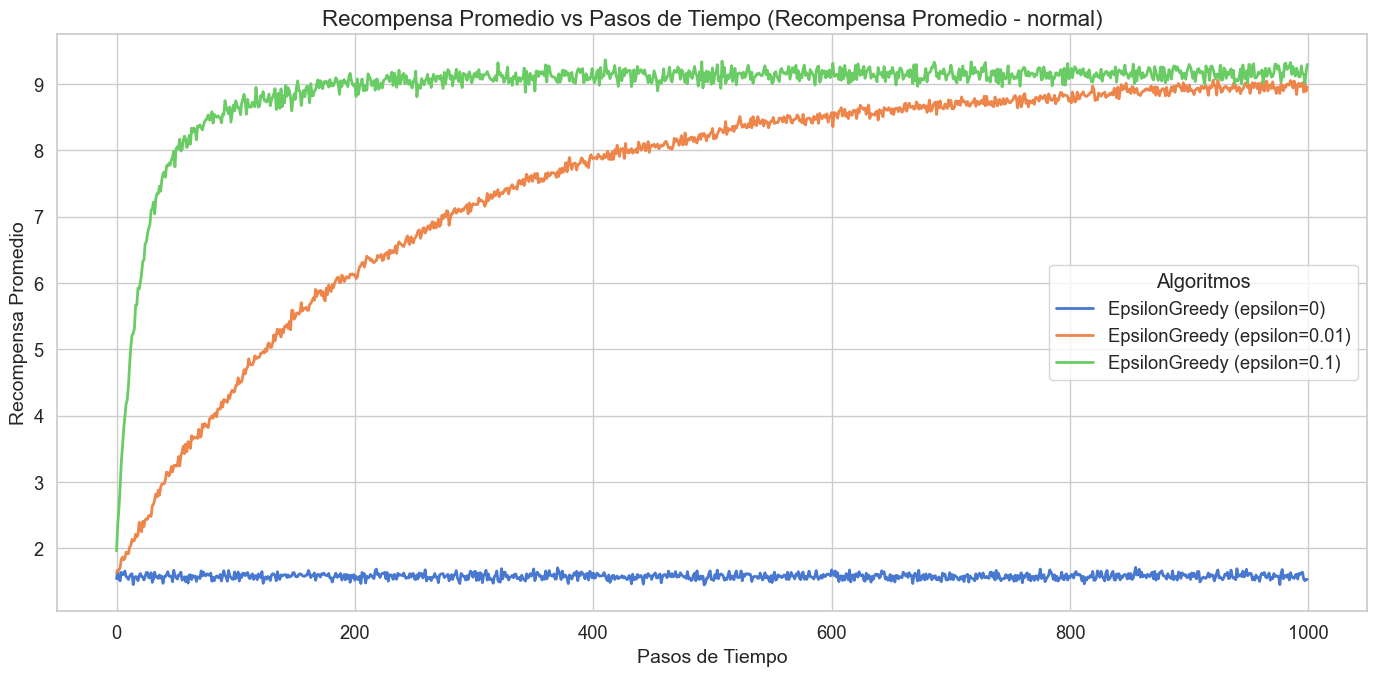

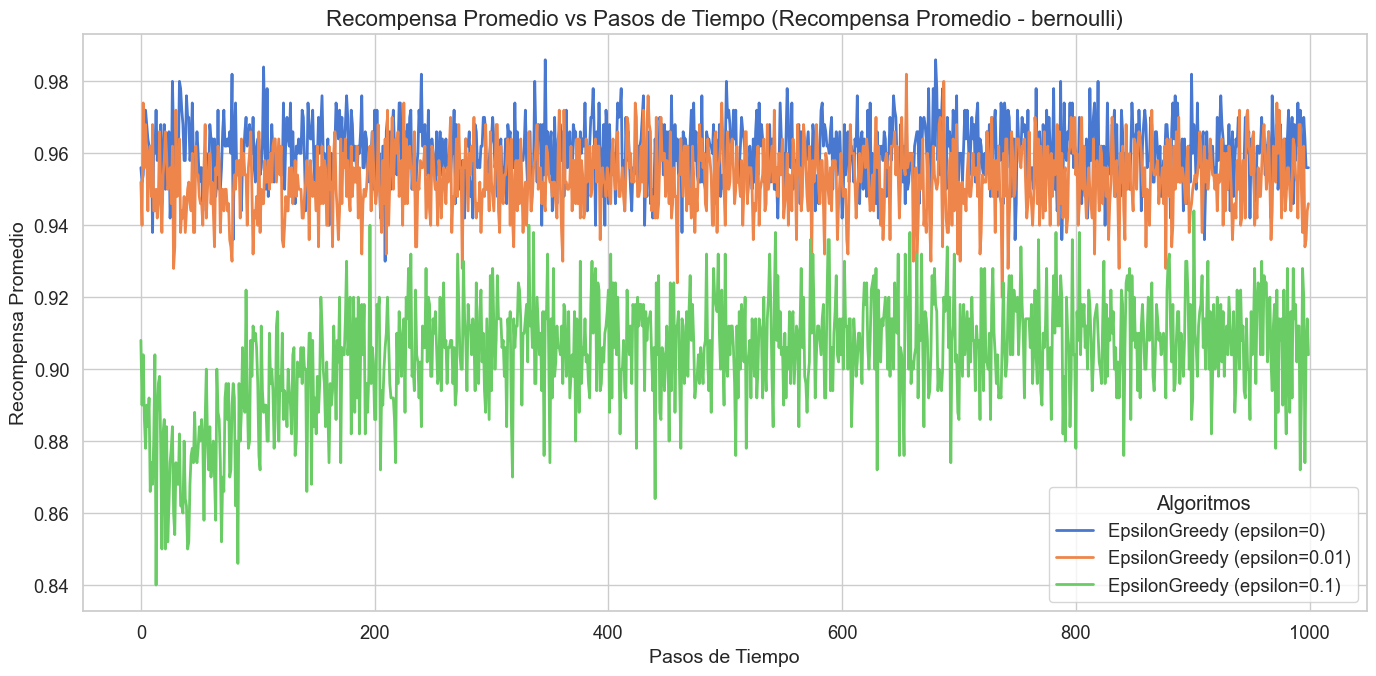

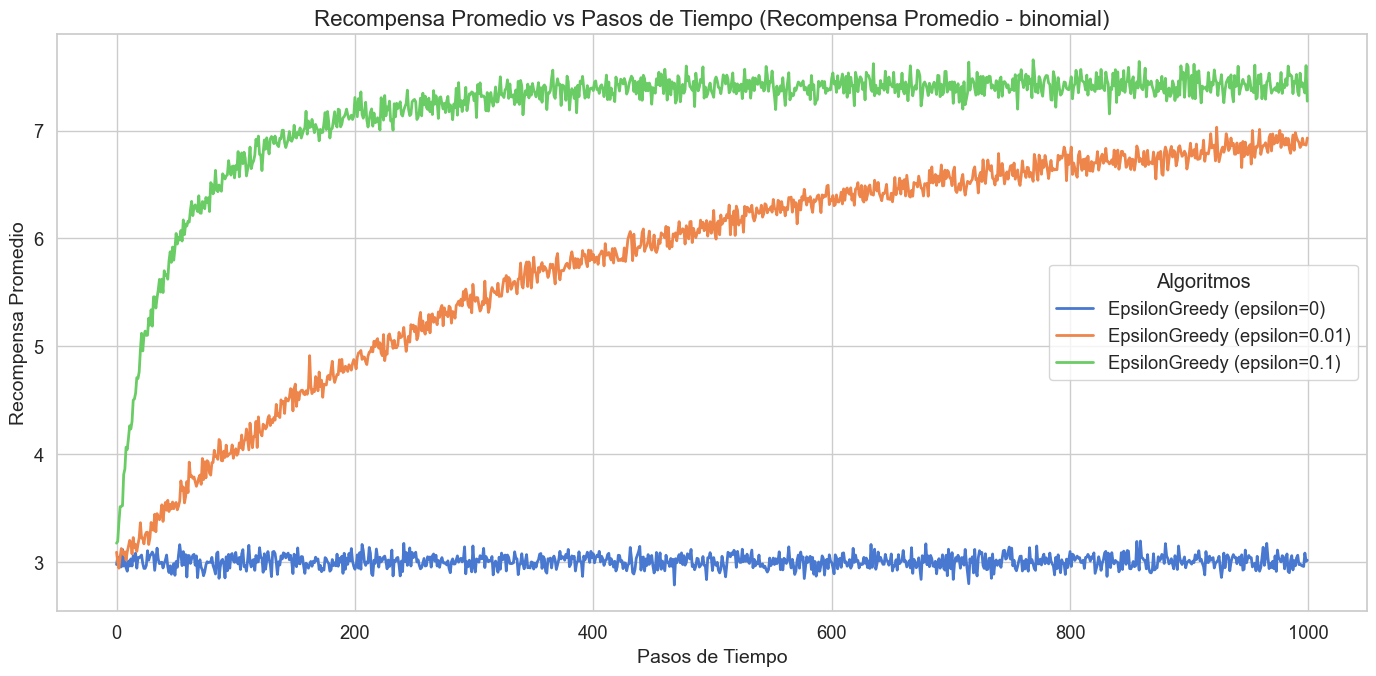

In [4]:
BanditExperiment.plot_rewards(results, steps, algorithms)

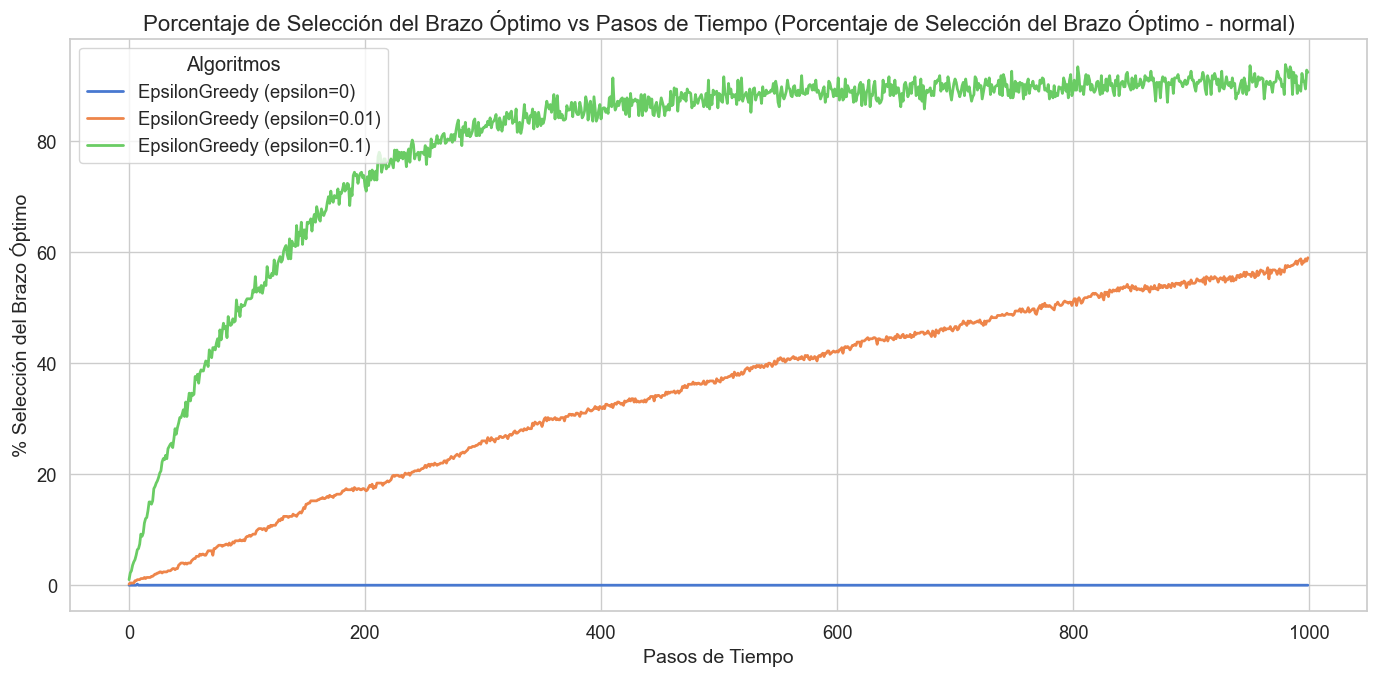

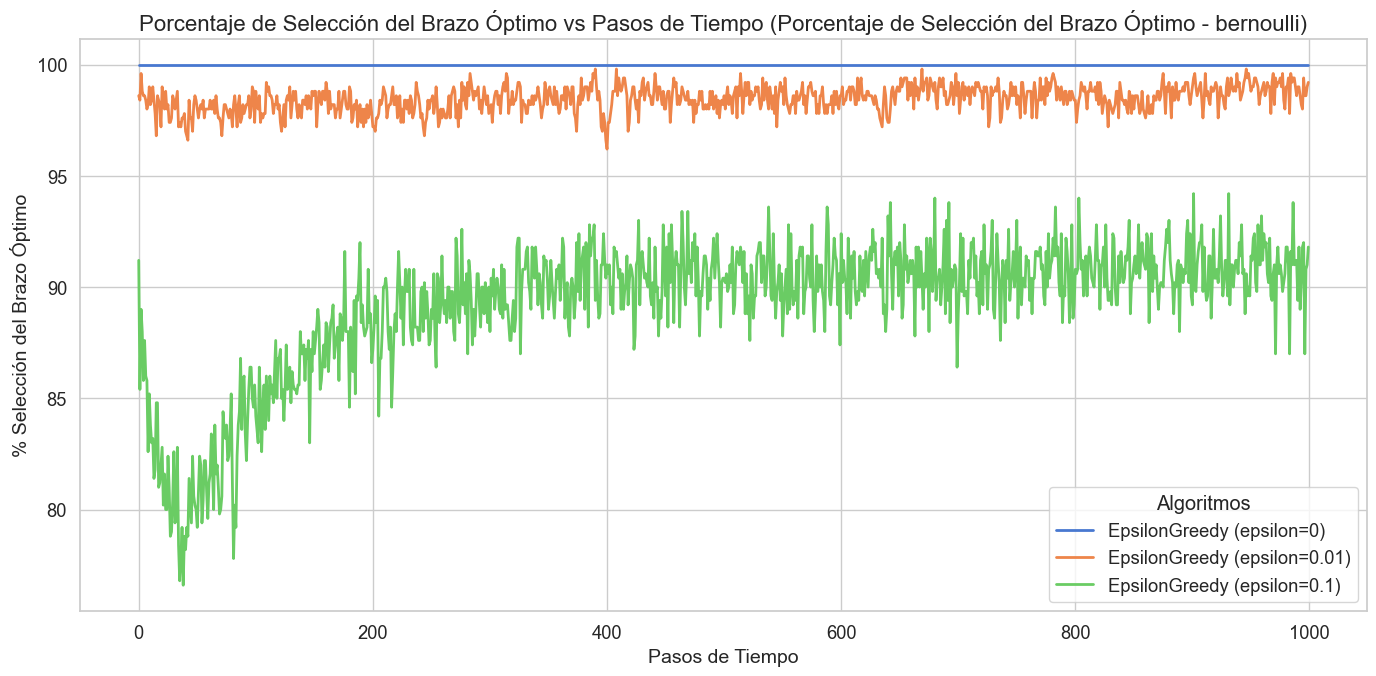

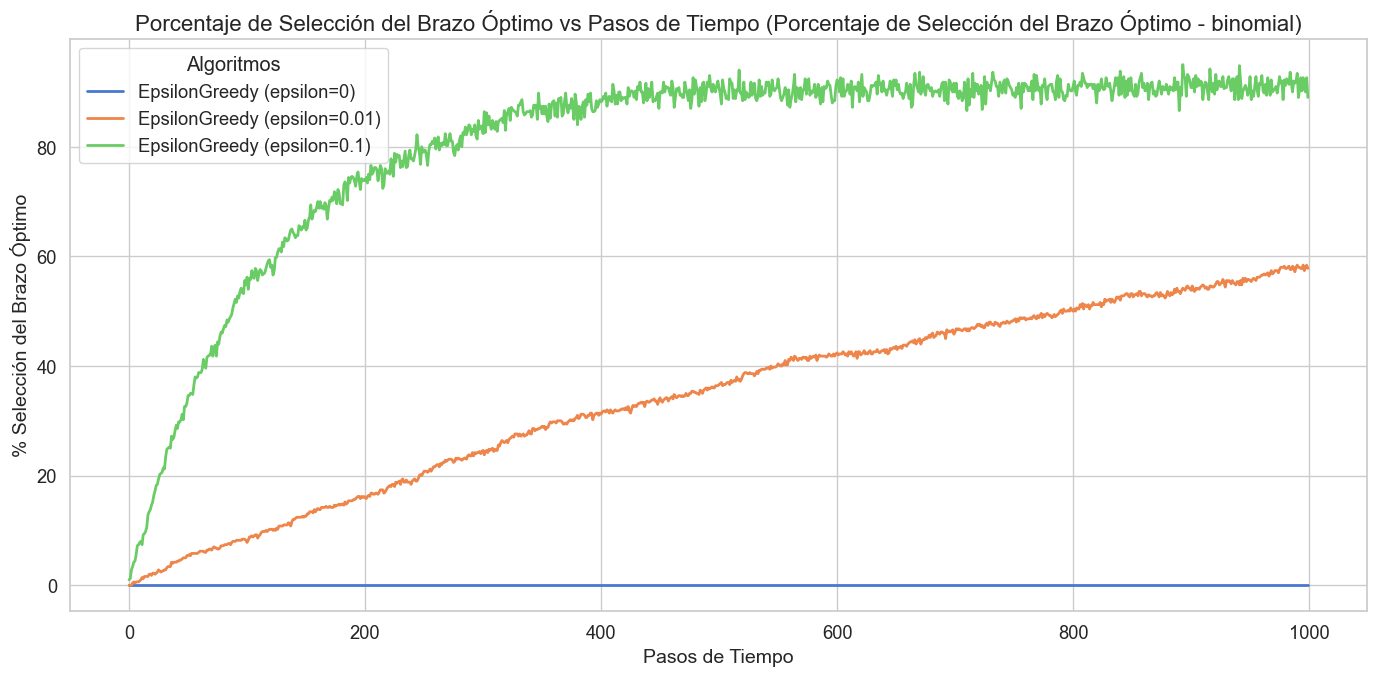

In [5]:
BanditExperiment.plot_optimal_selections(results, steps, algorithms)

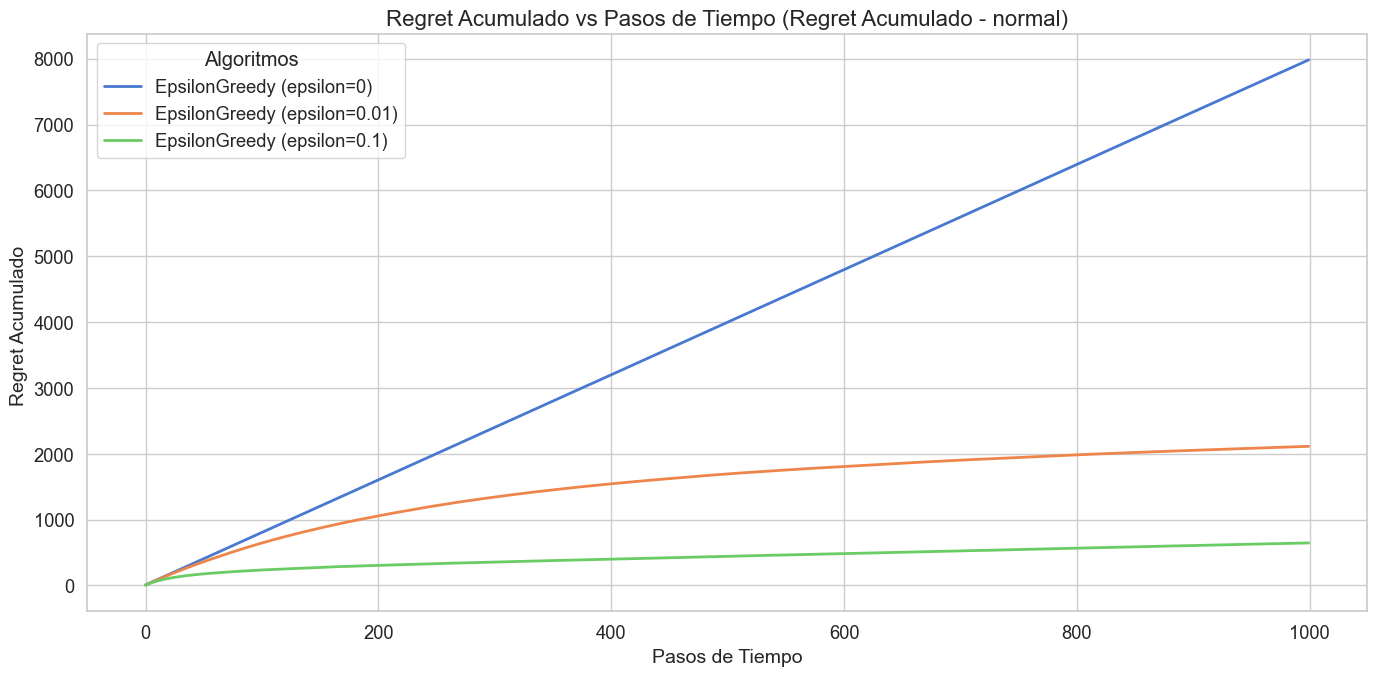

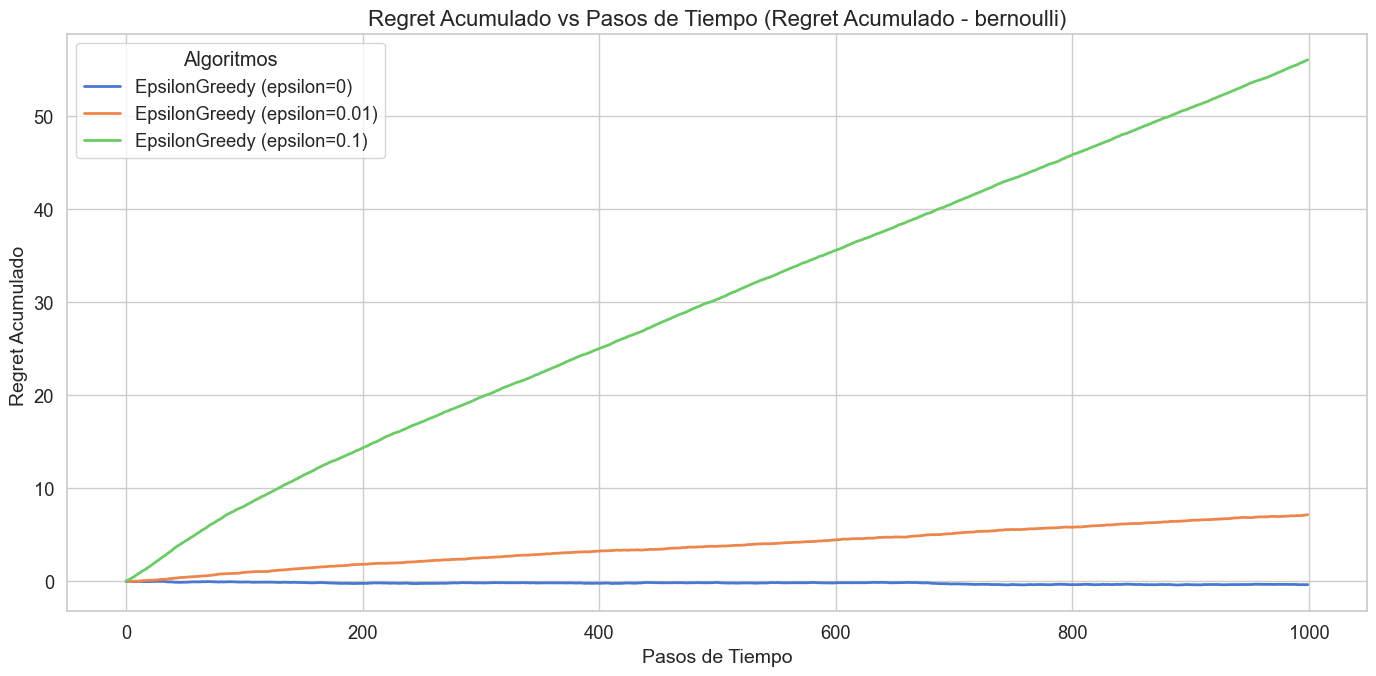

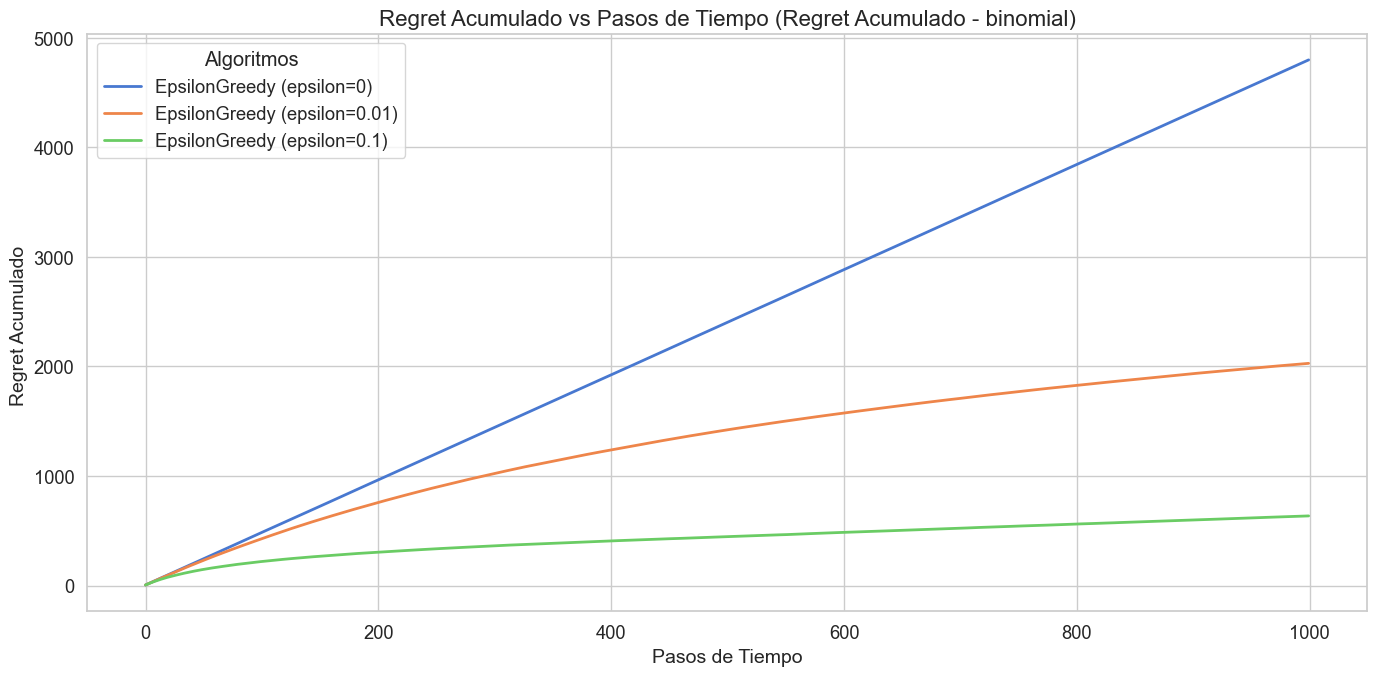

In [6]:
BanditExperiment.plot_regrets(results, steps, algorithms)

<Figure size 1400x700 with 0 Axes>

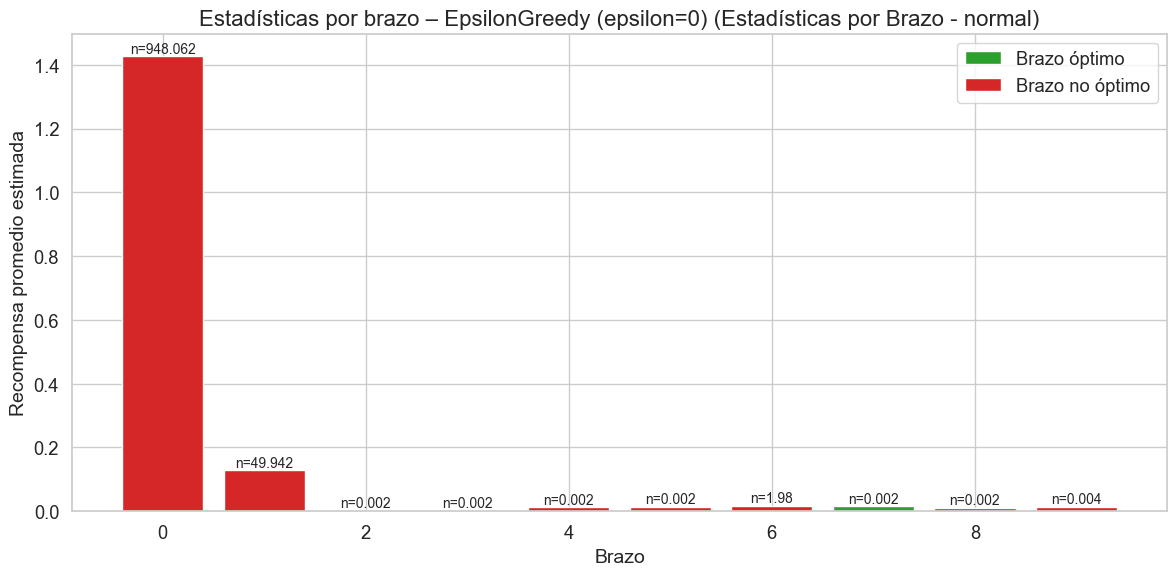

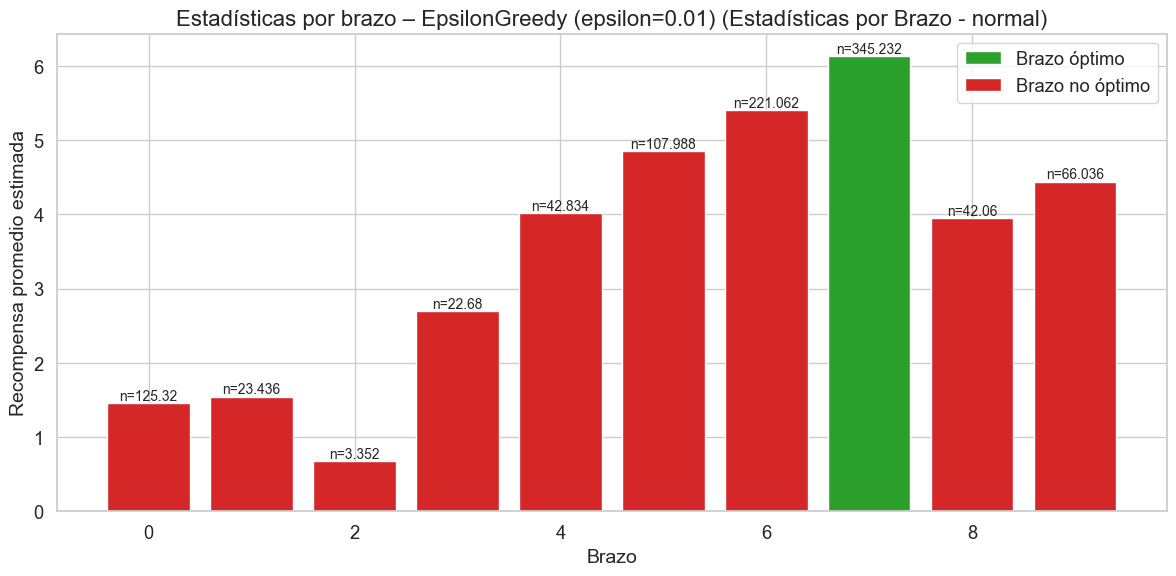

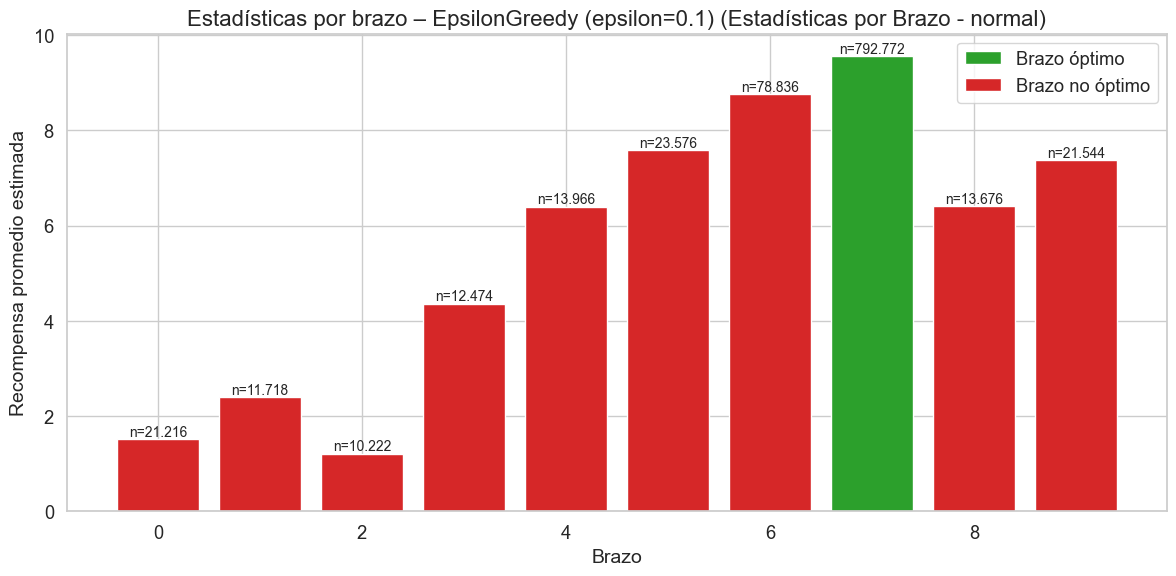

<Figure size 1400x700 with 0 Axes>

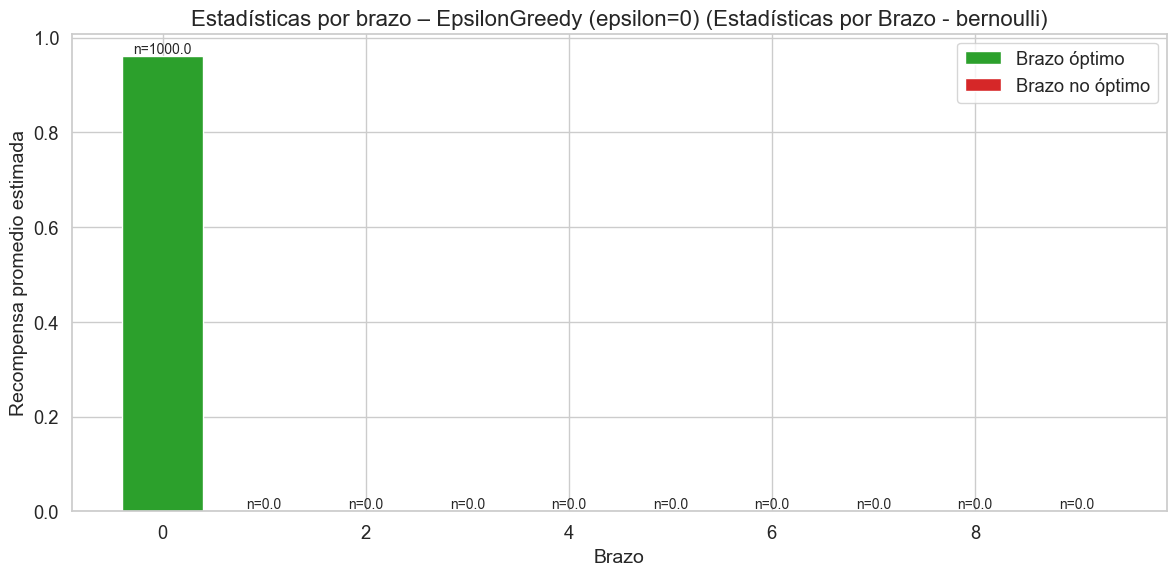

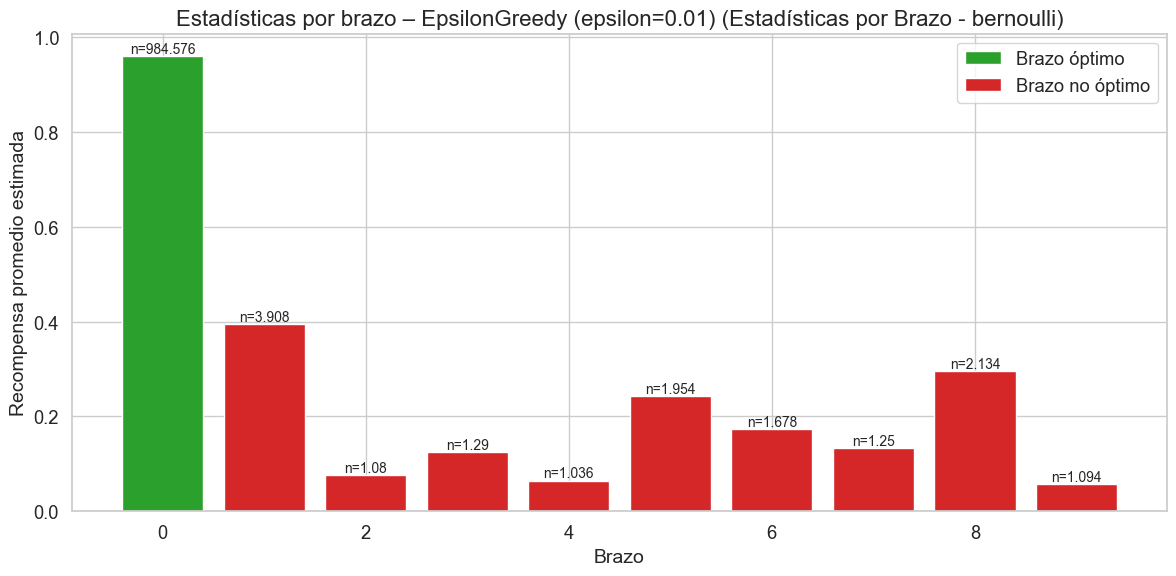

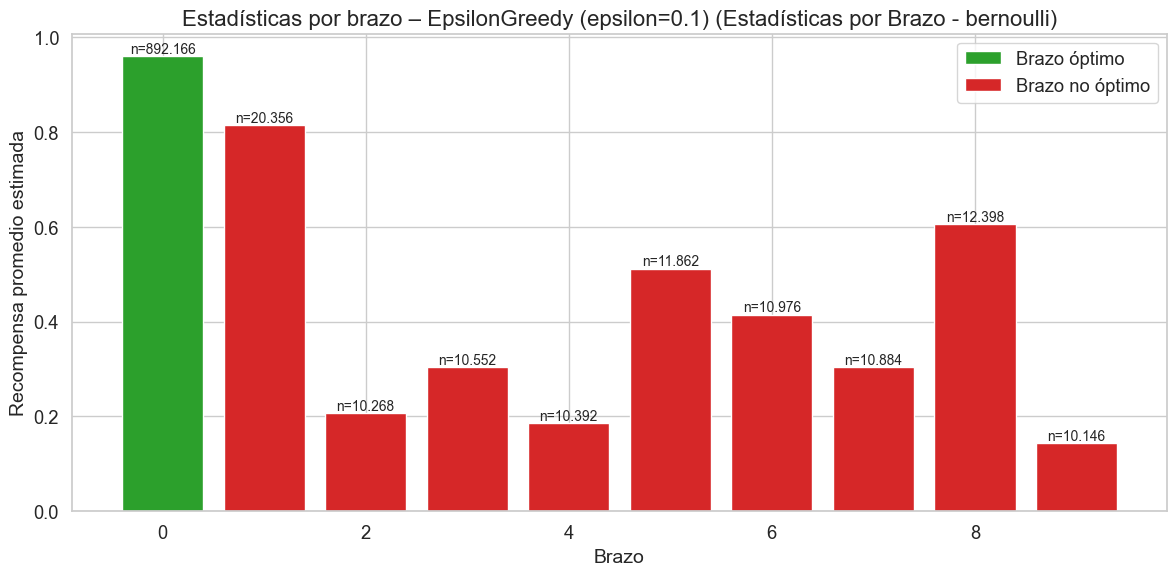

<Figure size 1400x700 with 0 Axes>

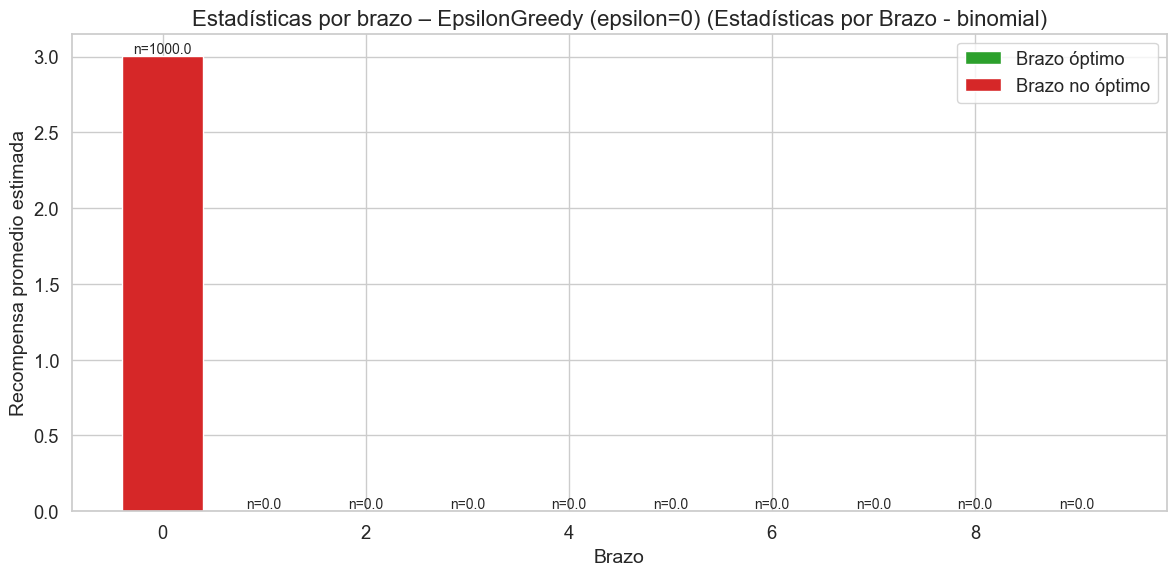

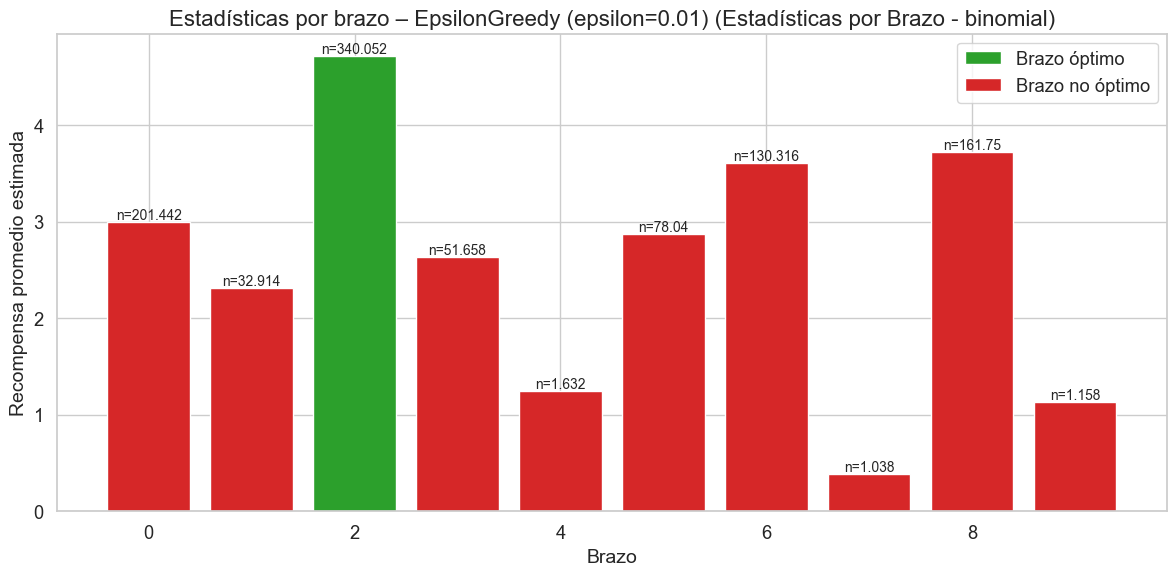

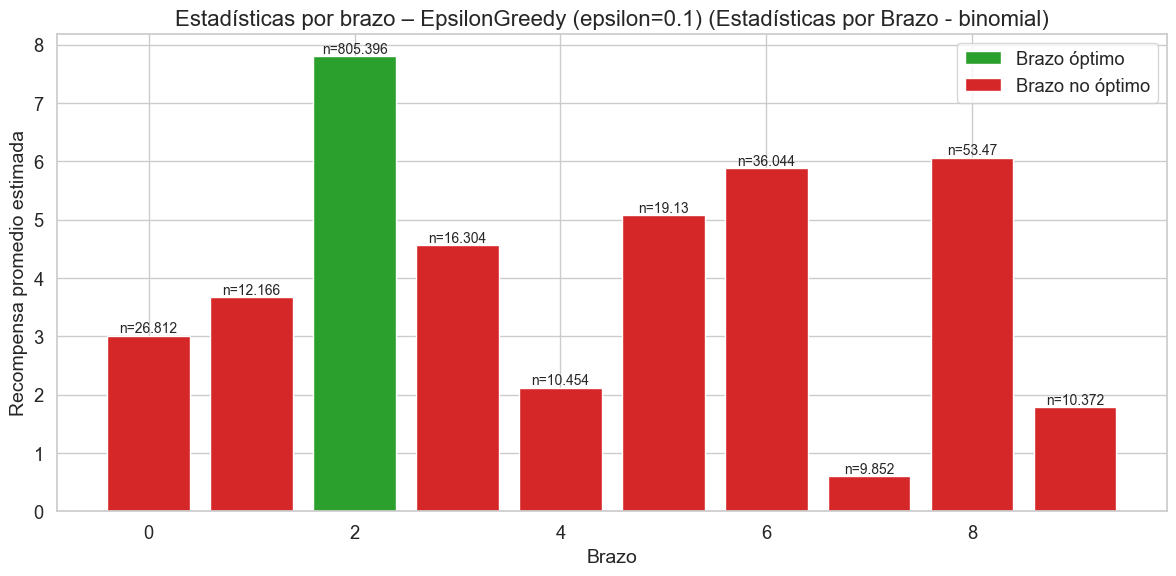

In [7]:
for name in [NORMAL_NAME,BERNOULLI_NAME,BINOMIAL_NAME]:
    BanditExperiment.plot_arm_statistics(bandits[name], results[name], algorithms, name)